In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f as fdist

rng = np.random.default_rng(0)   # fixed seed for the notebook; robustness across seeds checked at the end

In [ ]:
# Parameters (constant coefficients, per the brief)
n      = 1        # 1 = stochastic-VOL model,
# n      = 2        # 2 = stochastic-VARIANCE model
dt     = 1.0      # time increment Delta t
kappa  = 0.10     # mean-reversion speed. alpha = kappa*(theta - sigma^n); alpha may depend on sigma (brief allows it)
theta  = 0.01     # baseline level sigma^n reverts to when omega = 1
nu     = 0.0015   # vol-of-vol
rho    = -0.5     # corr between price shock eps and vol shock (leverage)
sigma0 = 0.01     # starting vol
S0     = 100.0    # starting price

# Event schedule: ONE periodic event; omega = 1 elsewhere
N         = 4000  # number of steps
period    = 40    # one event every `period` steps
amp       = 0.6   # omega jumps to (1 + amp) at the event
phi       = 0.85  # geometric decay of the omega excess back to 1
decay_len = 25    # steps over which the decayed excess is applied

In [3]:
# Build the event path and integrate eqs (1)-(2)
event_steps = np.arange(period, N, period)
is_event = np.zeros(N, dtype=int); is_event[event_steps] = 1   # binary event indicator

omega = np.ones(N)
for e in event_steps:
    for k in range(decay_len):
        if e + k < N:
            omega[e + k] += amp * (phi ** k)      # excess decays geometrically -> known half-life
true_half_life = np.log(0.5) / np.log(phi)

S = np.empty(N); S[0] = S0
sigma = np.empty(N); sigma[0] = sigma0
FLOOR = 1e-9    # numerical guard: additive noise can push n=1 vol negative (not a modelling choice)

for i in range(N-1):
    eps = rng.normal(0.0, np.sqrt(dt))            # price shock eps ~ N(0, dt)
    eta = rng.normal(0.0, np.sqrt(dt))            # independent vol shock eta ~ N(0, dt)
    S[i+1] = S[i] + sigma[i]*S[i]*eps             # eq (1)
    alpha  = kappa*(theta - sigma[i]**n)          # eq (2) drift term (mean-reverting)
    base   = sigma[i]**n + alpha*dt + nu*(rho*eps + np.sqrt(1-rho**2)*eta)   # F_i
    base   = max(base, FLOOR)
    sigma[i+1] = (omega[i+1]**(n/2) * base)**(1.0/n)   # eq (2): omega^{n/2} scales F_i

print(f"events: {len(event_steps)} | planted omega half-life: {true_half_life:.2f} steps")

events: 99 | planted omega half-life: 4.27 steps


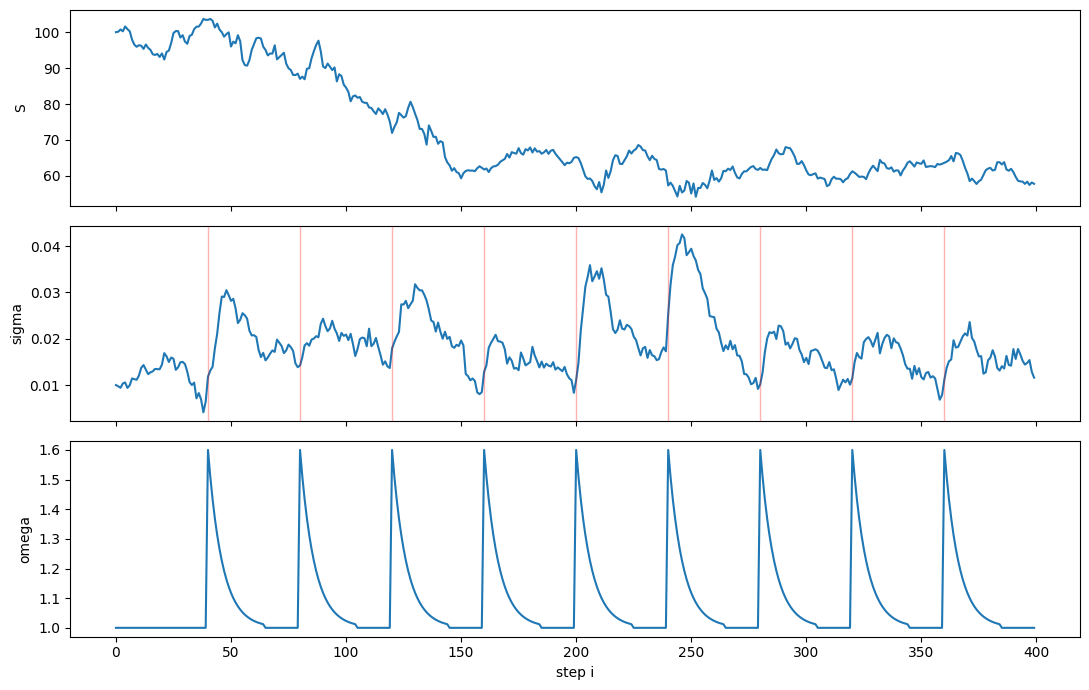

In [4]:
# - Plot the generated series -
w = slice(0, 400)
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].plot(S[w]);     ax[0].set_ylabel("S")
ax[1].plot(sigma[w]); ax[1].set_ylabel("sigma")
for e in event_steps[event_steps < 400]:
    ax[1].axvline(e, color="r", alpha=0.3, lw=1)
ax[2].plot(omega[w]); ax[2].set_ylabel("omega"); ax[2].set_xlabel("step i")
plt.tight_layout(); plt.show()

In [ ]:
# - Shared methods (written once) -
def granger_f(y, x, p):
    "Does x Granger-cause y at lag order p? Nested OLS F-test. Returns (F, p-value, 5% critical F)."
    y=np.asarray(y,float); x=np.asarray(x,float); Nn=len(y); yt=y[p:]
    ylags=np.column_stack([y[p-1-k:Nn-1-k] for k in range(p)])
    xlags=np.column_stack([x[p-1-k:Nn-1-k] for k in range(p)])
    const=np.ones((len(yt),1))
    Xr=np.hstack([const,ylags]); Xf=np.hstack([const,ylags,xlags])
    def rss(D,t):
        b,*_=np.linalg.lstsq(D,t,rcond=None); r=t-D@b; return r@r
    RSSr,RSSf=rss(Xr,yt),rss(Xf,yt)
    df1,df2=p,len(yt)-Xf.shape[1]
    F=((RSSr-RSSf)/df1)/(RSSf/df2)
    return F, 1-fdist.cdf(F,df1,df2), fdist.ppf(0.95,df1,df2)

def _discretize(z, bins):
    z=np.asarray(z,float)
    if len(np.unique(z))<=bins:
        _,inv=np.unique(z,return_inverse=True); return inv
    edges=np.quantile(z,np.linspace(0,1,bins+1)); edges[0]-=1e-9; edges[-1]+=1e-9
    return np.clip(np.digitize(z,edges)-1,0,bins-1)

def mutual_information(a, b, bins=16):
    "MI(a;b) in nats via a binned joint histogram (symmetric)."
    ad=_discretize(a,bins); bd=_discretize(b,bins)
    joint=np.zeros((ad.max()+1,bd.max()+1)); np.add.at(joint,(ad,bd),1.0); joint/=joint.sum()
    px=joint.sum(1,keepdims=True); py=joint.sum(0,keepdims=True); m=joint>0
    return float(np.sum(joint[m]*np.log(joint[m]/(px@py)[m])))

def tdmi(x, y, lags, bins=16):
    "Time-delayed MI: MI(x_t ; y_{t-L}). L>0 means y leads x."
    x=np.asarray(x,float); y=np.asarray(y,float); out=[]
    for L in lags:
        if L>=0: xa,ya=x[L:], y[:len(y)-L]
        else:    xa,ya=x[:len(x)+L], y[-L:]
        out.append(mutual_information(xa,ya,bins))
    return np.array(out)

def event_offset(is_event):
    "offset[t] = steps since most recent event (large if none yet)."
    M=len(is_event); off=np.full(M,10**6); last=-10**6
    for t in range(M):
        if is_event[t]: last=t
        off[t]=t-last
    return off

## Step 1 - Granger causality / TDMI between the volatility and the binary event indicator

GRANGER CAUSALITY (p=15)
  event -> sigma :  F=34.66  p=0.00e+00  crit=1.67  -> SIG
  sigma -> event :  F=10.57  p=0.00e+00  crit=1.67  -> SIG
  (sigma->event is a periodicity false positive: events are exogenous by construction)

TDMI (level)  peak at lag L = -1  (two-humped, direction not identified)
TDMI (change) peak at lag L = 1  (L>0 => event leads sigma)


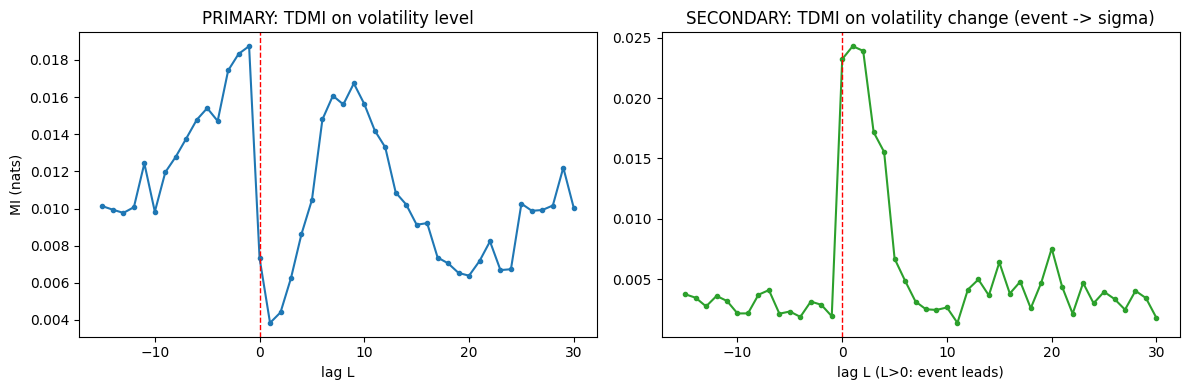

In [6]:
#  Granger causality, both directions 
p = 15
F_ev, pv_ev, crit = granger_f(sigma, is_event, p)   # event -> sigma
F_ve, pv_ve, _    = granger_f(is_event, sigma, p)   # sigma -> event
print("GRANGER CAUSALITY (p=15)")
print(f"  event -> sigma :  F={F_ev:.2f}  p={pv_ev:.2e}  crit={crit:.2f}  -> {'SIG' if F_ev>crit else 'null'}")
print(f"  sigma -> event :  F={F_ve:.2f}  p={pv_ve:.2e}  crit={crit:.2f}  -> {'SIG' if F_ve>crit else 'null'}")
print("  (sigma->event is a periodicity false positive: events are exogenous by construction)")

lags = np.arange(-15, 31)

#  PRIMARY: TDMI on the volatility LEVEL (as the brief asks) 
mi_level = tdmi(sigma, is_event, lags)
print(f"\nTDMI (level)  peak at lag L = {lags[np.argmax(mi_level)]}  (two-humped, direction not identified)")

#  SECONDARY (labelled): TDMI on the volatility CHANGE, to recover direction 
mi_change = tdmi(np.diff(sigma**n), is_event[1:], lags)
print(f"TDMI (change) peak at lag L = {lags[np.argmax(mi_change)]}  (L>0 => event leads sigma)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(lags, mi_level, '-o', ms=3); ax[0].axvline(0, color='r', ls='--', lw=1)
ax[0].set_title("PRIMARY: TDMI on volatility level"); ax[0].set_xlabel("lag L"); ax[0].set_ylabel("MI (nats)")
ax[1].plot(lags, mi_change, '-o', ms=3, color='tab:green'); ax[1].axvline(0, color='r', ls='--', lw=1)
ax[1].set_title("SECONDARY: TDMI on volatility change (event -> sigma)"); ax[1].set_xlabel("lag L (L>0: event leads)")
plt.tight_layout(); plt.show()

## Step 2 - deduce the causal structure (parametric and non-parametric)

In [7]:
#  Parametric (GC) across directed pairs 
r     = np.diff(np.log(S))     # log-returns (S is non-stationary)
sig_a = sigma[:-1]; ev_a = is_event[:-1]; absr = np.abs(r)
p = 15
pairs = [("event","sigma",sig_a,ev_a), ("sigma","event",ev_a,sig_a),
         ("return","sigma",sig_a,r), ("sigma","return",r,sig_a),
         ("sigma","|return|",absr,sig_a), ("event","return",r,ev_a), ("event","|return|",absr,ev_a)]
print(f"{'cause':>8} -> {'effect':<9} {'F':>8} {'crit':>7}  verdict")
print("-"*46)
for cause,effect,y,x in pairs:
    F,pv,crit = granger_f(y,x,p)
    print(f"{cause:>8} -> {effect:<9} {F:>8.2f} {crit:>7.2f}  {'SIGNIFICANT' if F>crit else 'null'}")

   cause -> effect           F    crit  verdict
----------------------------------------------
   event -> sigma        34.72    1.67  SIGNIFICANT
   sigma -> event        10.59    1.67  SIGNIFICANT
  return -> sigma        73.68    1.67  SIGNIFICANT
   sigma -> return        0.87    1.67  null
   sigma -> |return|     35.15    1.67  SIGNIFICANT
   event -> return        2.04    1.67  SIGNIFICANT
   event -> |return|     13.13    1.67  SIGNIFICANT


In [8]:
#  Non-parametric (MI): dependence (symmetric) + lag-1 direction attempt 
print("DEPENDENCE (contemporaneous MI, nats):")
for a,b,x,y in [("event","sigma",ev_a,sig_a),("return","sigma",r,sig_a),
                ("|return|","sigma",absr,sig_a),("event","return",ev_a,r),("event","|return|",ev_a,absr)]:
    print(f"  {a:>8} <-> {b:<9} : MI = {mutual_information(x,y):.4f}")

def mi_lag(effect, cause, lag=1): return mutual_information(effect[lag:], cause[:-lag])
print("\nDIRECTION (lag-1 MI asymmetry; unconditioned, so unreliable under periodicity):")
for a,b,A,B in [("event","sigma",ev_a,sig_a),("return","sigma",r,sig_a)]:
    ab,ba = mi_lag(B,A), mi_lag(A,B)
    print(f"  {a}->{b}: {ab:.4f}  {b}->{a}: {ba:.4f}  ({'forward' if ab>ba else 'reverse'} stronger)")

DEPENDENCE (contemporaneous MI, nats):
     event <-> sigma     : MI = 0.0073
    return <-> sigma     : MI = 0.1335
  |return| <-> sigma     : MI = 0.1397
     event <-> return    : MI = 0.0022
     event <-> |return|  : MI = 0.0021

DIRECTION (lag-1 MI asymmetry; unconditioned, so unreliable under periodicity):
  event->sigma: 0.0038  sigma->event: 0.0187  (reverse stronger)
  return->sigma: 0.1315  sigma->return: 0.1208  (forward stronger)


## Step 3 - estimate the event weight $\omega$ (parametric and non-parametric)

omega peak: true 1.600 | parametric 1.524 | non-parametric 1.503
half-life : true 4.27 | parametric 4.11


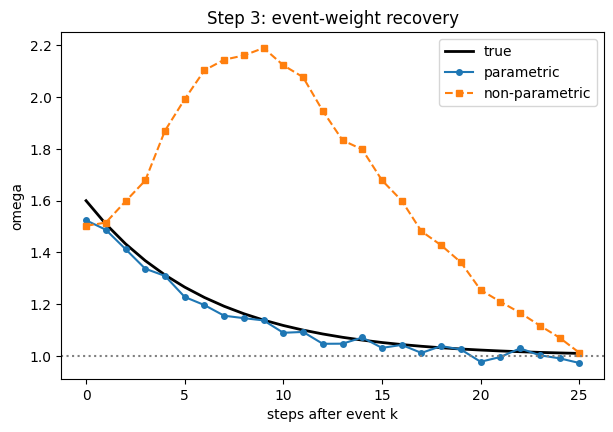

In [13]:
def estimate_omega(sigma, is_event, n, Kmax=25, calm_gap=30):
    x=sigma**n
    off=event_offset(is_event)
    xc,xn=x[:-1],x[1:]
    tgt=off[1:]
    
    calm = tgt >= calm_gap
    
    a,b=np.polyfit(xc[calm],xn[calm],1)[::-1]
    Fpar=lambda z: a+b*z          # parametric F - linear regression
    
    edges=np.quantile(xc[calm],np.linspace(0,1,13))
    edges[0]-=1e-12; edges[-1]+=1e-12
    bid = np.clip(np.digitize(xc[calm],edges)-1,0,len(edges)-2)
    bm = np.array([xn[calm][bid==j].mean() if (bid==j).any() else np.nan for j in range(len(edges)-1)])
    Fnp = lambda z: bm[np.clip(np.digitize(z,edges)-1,0,len(edges)-2)]         # non-parametric F - binned conditional mean of sigma^n{i+1} given sigma^n{i}
    ks=np.arange(Kmax+1)
    wp=np.array([(xn[tgt==k].mean()/Fpar(xc[tgt==k]).mean())**(2.0/n) for k in ks])  # invert n/2
    wn=np.array([(xn[tgt==k].mean()/Fnp (xc[tgt==k]).mean())**(2.0/n) for k in ks])
    return ks, wp, wn, (a,b)

def recover_half_life(ks, w, kfit=12):
    ex=w[:kfit]-1; good=ex>1e-3
    if good.sum()<3: return np.nan
    slope=np.polyfit(ks[:kfit][good], np.log(ex[good]),1)[0]
    return np.log(0.5)/slope if slope<0 else np.nan

ks, w_par, w_np, (a,b) = estimate_omega(sigma, is_event, n)
w_true = 1 + amp*phi**ks
print(f"omega peak: true {w_true[0]:.3f} | parametric {w_par[0]:.3f} | non-parametric {w_np[0]:.3f}")
print(f"half-life : true {true_half_life:.2f} | parametric {recover_half_life(ks,w_par):.2f}")

plt.figure(figsize=(7,4.5))
plt.plot(ks,w_true,'k-',lw=2,label='true'); plt.plot(ks,w_par,'o-',ms=4,label='parametric')
plt.plot(ks,w_np,'s--',ms=4,label='non-parametric'); plt.axhline(1,color='grey',ls=':')
plt.xlabel('steps after event k'); plt.ylabel('omega'); plt.legend(); plt.title('Step 3: event-weight recovery'); plt.show()

## Step 4 & 5 - predict $\sigma$ with eq (7); accuracy and calibration with eqs (8–9)

leverage coef c=nu*rho estimated: -0.000802  (true -0.00075)
prediction (eq 7) vs no-event baseline:
  ALL   RMSE  1.933e-03 -> 1.378e-03  (+29%)
  EVENT RMSE  2.923e-03 -> 1.501e-03  (+49%)
calibration (eq 8-9): overall 94.2%  [event 93.9%  calm 94.4%]  (target 95%)


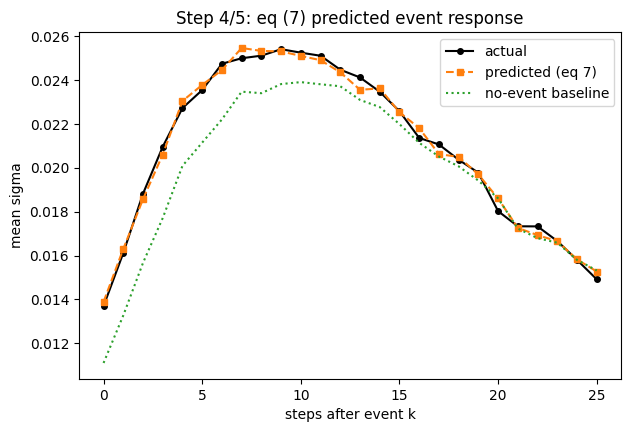

In [10]:
def predict_sigma(sigma, S, is_event, n, Kmax=25, calm_gap=30, train_frac=0.7):
    x=sigma**n; off=event_offset(is_event)
    eps=(S[1:]-S[:-1])/(sigma[:-1]*S[:-1])              # = eps_i exactly (eq 1)
    xc,xn=x[:-1],x[1:]; tgt=off[1:]
    T=int(len(xc)*train_frac); calm=tgt>=calm_gap; trc=calm.copy(); trc[T:]=False
    D=np.column_stack([np.ones(trc.sum()),xc[trc],eps[trc]])                 # eq(7) bracket: a+b*sig^n+c*eps
    a,b,c=np.linalg.lstsq(D,xn[trc],rcond=None)[0]
    bracket=lambda xc_,e_: a+b*xc_+c*e_
    s_perp=np.std(xn[trc]-bracket(xc[trc],eps[trc]))                         # eq(9) orthogonal-shock std
    w=np.ones(Kmax+1)
    for k in range(Kmax+1):
        m=(tgt==k); m[T:]=False
        if m.any(): w[k]=(xn[m].mean()/bracket(xc[m],eps[m]).mean())**(2.0/n)
    te=slice(T,None); mult=w[np.clip(tgt[te],0,Kmax)]**(n/2)
    x_pred=mult*bracket(xc[te],eps[te])                 # eq (7) mean
    x_base=bracket(xc[te],eps[te])                      # no-event baseline (omega=1)
    x_act=xn[te]; pred_sd=mult*s_perp                   # eq (8-9) per-step sd
    return x_pred, x_base, x_act, tgt[te], pred_sd, (a,b,c)

x_pred,x_base,x_act,tg,pred_sd,(a,b,c)=predict_sigma(sigma,S,is_event,n)
def rmse(p,m=None): e=(x_act-p); e=e if m is None else e[m]; return np.sqrt(np.mean(e**2))
def mae (p,m=None): e=np.abs(x_act-p); e=e if m is None else e[m]; return np.mean(e)
win=tg<=10
print(f"leverage coef c=nu*rho estimated: {c:.6f}  (true {nu*rho})")
print("prediction (eq 7) vs no-event baseline:")
print(f"  ALL   RMSE  {rmse(x_base):.3e} -> {rmse(x_pred):.3e}  ({100*(1-rmse(x_pred)/rmse(x_base)):+.0f}%)")
print(f"  EVENT RMSE  {rmse(x_base,win):.3e} -> {rmse(x_pred,win):.3e}  ({100*(1-rmse(x_pred,win)/rmse(x_base,win)):+.0f}%)")
def cov(m=None):
    ok=(x_act>=x_pred-1.96*pred_sd)&(x_act<=x_pred+1.96*pred_sd)
    return (np.mean(ok[m]) if m is not None else np.mean(ok))*100
print(f"calibration (eq 8-9): overall {cov():.1f}%  [event {cov(win):.1f}%  calm {cov(~win):.1f}%]  (target 95%)")

ks=np.arange(26)
pa=np.array([x_act[tg==k].mean()**(1/n) for k in ks]); pp=np.array([x_pred[tg==k].mean()**(1/n) for k in ks])
pb=np.array([x_base[tg==k].mean()**(1/n) for k in ks])
plt.figure(figsize=(7,4.5))
plt.plot(ks,pa,'k-o',ms=4,label='actual'); plt.plot(ks,pp,'s--',ms=4,color='tab:orange',label='predicted (eq 7)')
plt.plot(ks,pb,':',lw=1.5,color='tab:green',label='no-event baseline')
plt.xlabel('steps after event k'); plt.ylabel('mean sigma'); plt.legend(); plt.title('Step 4/5: eq (7) predicted event response'); plt.show()

## Step 6 - repeat across values and functional forms

In [11]:
def simulate(omega, seed=0, n=1, N=4000, period=40, kappa=0.10, theta=0.01,
             nu=0.0015, rho=-0.5, dt=1.0, sigma0=0.01, S0=100.0, want_S=False):
    rng=np.random.default_rng(seed); ev=np.arange(period,N,period); ie=np.zeros(N,int); ie[ev]=1
    sg=np.empty(N); sg[0]=sigma0; Sx=np.empty(N); Sx[0]=S0; FL=1e-9
    for i in range(N-1):
        eps=rng.normal(0,np.sqrt(dt)); eta=rng.normal(0,np.sqrt(dt))
        if want_S: Sx[i+1]=Sx[i]+sg[i]*Sx[i]*eps
        base=max(sg[i]**n + kappa*(theta-sg[i]**n)*dt + nu*(rho*eps+np.sqrt(1-rho**2)*eta), FL)
        sg[i+1]=(omega[i+1]**(n/2)*base)**(1.0/n)
    return sg, ie, Sx

def geometric_omega(N, period, amp, phi, decay_len):
    om=np.ones(N)
    for e in np.arange(period,N,period):
        for k in range(decay_len):
            if e+k<N: om[e+k]+=amp*(phi**k)
    return om

def hump_omega(N, period, amp, kp, decay_len):
    om=np.ones(N)
    for e in np.arange(period,N,period):
        for k in range(decay_len):
            if e+k<N: om[e+k]+=amp*(k/kp)*np.exp(1-k/kp)
    return om

#  value sweep (slow decay phi=0.95 needs a wider period so pulses don't overlap) 
print("VALUE SWEEP")
print(f"{'n':>2}{'amp':>5}{'phi':>6}{'per':>5} | {'HLtrue':>7}{'HLpar':>7} | {'Wtrue':>7}{'Wpar':>7}")
for (nn,am,ph,dl,per,cg) in [(1,0.6,0.85,25,40,30),(1,1.2,0.85,25,40,30),
                             (1,0.6,0.95,60,120,80),(2,0.6,0.85,25,40,30),(2,0.8,0.85,25,40,30)]:
    sg,ie,_=simulate(geometric_omega(N,per,am,ph,dl), seed=0, n=nn, period=per)
    kk,wp,_,_=estimate_omega(sg,ie,nn,calm_gap=cg)
    print(f"{nn:>2}{am:>5}{ph:>6}{per:>5} | {np.log(0.5)/np.log(ph):>7.2f}{recover_half_life(kk,wp):>7.2f} | {1+am:>7.3f}{wp[0]:>7.3f}")

#  ablation experiments 
print("\nEXPERIMENTS")
sg,ie,_=simulate(np.ones(N),seed=0); F,_,crit=granger_f(sg,ie,15); _,wpA,_,_=estimate_omega(sg,ie,1)
print(f"A null (amp=0): event->sigma F={F:.2f} (crit {crit:.2f}) -> {'SIG' if F>crit else 'null'} | omega-hat mean {wpA.mean():.3f}")
sg,ie,Sx=simulate(geometric_omega(N,period,0.6,0.85,25),seed=0,rho=0.0,want_S=True)
rr=np.diff(np.log(Sx)); Frs,_,cB=granger_f(sg[:-1],rr,15); Fev,_,_=granger_f(sg,ie,15)
print(f"B rho=0: return->sigma F={Frs:.2f} -> {'SIG' if Frs>cB else 'null'} (was SIG) | event->sigma F={Fev:.2f} -> SIG | MI(sig;r)={mutual_information(sg[:-1],rr):.3f}")
sg,ie,_=simulate(hump_omega(N,period,1.5,5,25),seed=0); kk,wpC,_,_=estimate_omega(sg,ie,1)
print(f"C hump: recovered peak k={kk[np.argmax(wpC)]} (true 5), value {wpC.max():.3f} (true 2.500)")

VALUE SWEEP
 n  amp   phi  per |  HLtrue  HLpar |   Wtrue   Wpar
 1  0.6  0.85   40 |    4.27   4.11 |   1.600  1.524
 1  1.2  0.85   40 |    4.27   4.21 |   2.200  2.129
 1  0.6  0.95  120 |   13.51  14.66 |   1.600  1.638
 2  0.6  0.85   40 |    4.27   4.22 |   1.600  1.579
 2  0.8  0.85   40 |    4.27   4.27 |   1.800  1.800

EXPERIMENTS
A null (amp=0): event->sigma F=0.87 (crit 1.67) -> null | omega-hat mean 0.981
B rho=0: return->sigma F=1.43 -> null (was SIG) | event->sigma F=33.74 -> SIG | MI(sig;r)=0.130
C hump: recovered peak k=5 (true 5), value 2.500 (true 2.500)


## Robustness across seeds

In [12]:
seeds=range(10); HL,PW,EVI,COV=[],[],[],[]
for s in seeds:
    om=geometric_omega(N,period,0.6,0.85,25)
    sg,ie,Sx=simulate(om,seed=s,n=1,want_S=True)     # want_S=True: eq 7 needs prices
    kk,wp,_,_=estimate_omega(sg,ie,1)
    HL.append(recover_half_life(kk,wp)); PW.append(wp[0])
    xp,xb,xa,tgs,psd,_=predict_sigma(sg,Sx,ie,1)
    wn=tgs<=10
    rm=np.sqrt(np.mean((xa[wn]-xp[wn])**2)); rb=np.sqrt(np.mean((xa[wn]-xb[wn])**2))
    cv=np.mean((xa>=xp-1.96*psd)&(xa<=xp+1.96*psd))
    EVI.append(100*(1-rm/rb)); COV.append(cv*100)
HL,PW,EVI,COV=map(np.array,(HL,PW,EVI,COV))
print(f"across seeds 0-9 (true HL={true_half_life:.2f}, true peak omega={1+amp:.3f}):")
print(f"  half-life  : {HL.mean():.2f} +/- {HL.std():.2f}  (range {HL.min():.2f}-{HL.max():.2f})")
print(f"  peak omega : {PW.mean():.3f} +/- {PW.std():.3f}")
print(f"  event RMSE improvement : {EVI.mean():.0f}% +/- {EVI.std():.0f}%")
print(f"  95% coverage : {COV.mean():.1f}% +/- {COV.std():.1f}%")

across seeds 0-9 (true HL=4.27, true peak omega=1.600):
  half-life  : 4.35 +/- 0.26  (range 3.93-4.77)
  peak omega : 1.615 +/- 0.056
  event RMSE improvement : 52% +/- 2%
  95% coverage : 95.3% +/- 0.8%
